1. ĐANG LOAD DỮ LIỆU...
✅ X_train shape: (4852, 15) | y_train phân bố: 55.4% Home Win
✅ X_test shape:  (1209, 15)  | y_test phân bố:  55.3% Home Win

2. ĐANG HUẤN LUYỆN MÔ HÌNH...
✅ Huấn luyện xong!

3. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (OUT-OF-TIME)
--- Mô hình: Logistic Regression Baseline ---
Accuracy : 0.6559 (Độ chính xác tổng thể)
ROC-AUC  : 0.7107 (Khả năng phân tách Thắng/Thua)
F1-Score : 0.7115

Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.64      0.52      0.57       540
Home Win (1)       0.66      0.77      0.71       669

    accuracy                           0.66      1209
   macro avg       0.65      0.64      0.64      1209
weighted avg       0.65      0.66      0.65      1209



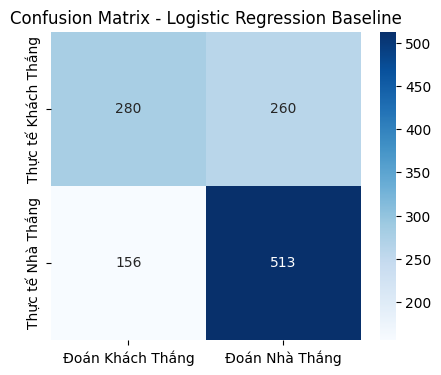



--- Mô hình: XGBoost Classifier ---
Accuracy : 0.6625 (Độ chính xác tổng thể)
ROC-AUC  : 0.7115 (Khả năng phân tách Thắng/Thua)
F1-Score : 0.7205

Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.66      0.51      0.57       540
Home Win (1)       0.66      0.79      0.72       669

    accuracy                           0.66      1209
   macro avg       0.66      0.65      0.65      1209
weighted avg       0.66      0.66      0.66      1209



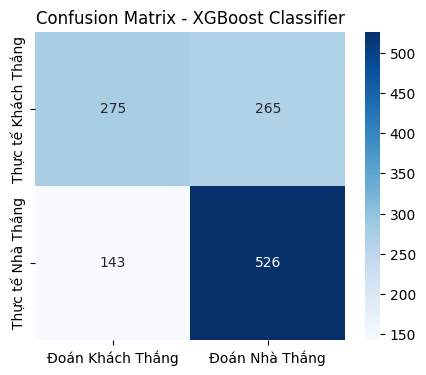


4. MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (FEATURE IMPORTANCE)


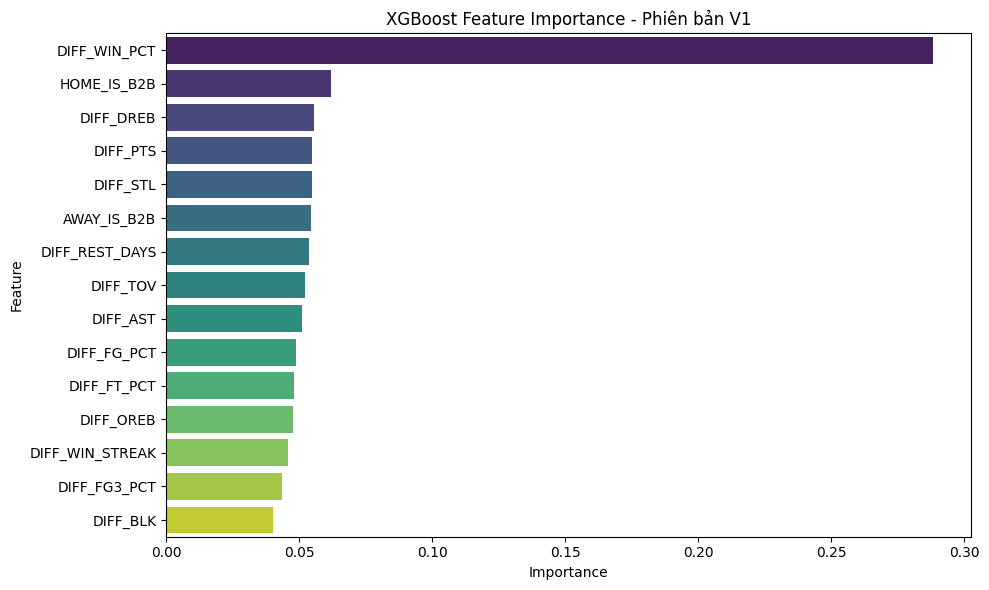

In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện Machine Learning
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

# 1. Đọc file cấu hình và dữ liệu
print("1. ĐANG LOAD DỮ LIỆU...")
try:
    with open(r'C:\Code_AI\CS114-FinalTerm\FeatureEngineering\V1\output\feature_config_v1.json', 'r', encoding='utf-8') as f:
        config = json.load(f)
    FEATURES = config['feature_set']
    LABEL = config['label']
except FileNotFoundError:
    print("⚠️ Không tìm thấy file JSON. Đang dùng danh sách thủ công...")
    FEATURES = ['DIFF_PTS', 'DIFF_FG_PCT', 'DIFF_FG3_PCT', 'DIFF_FT_PCT', 'DIFF_OREB', 
                'DIFF_DREB', 'DIFF_AST', 'DIFF_STL', 'DIFF_BLK', 'DIFF_TOV', 
                'DIFF_WIN_PCT', 'DIFF_WIN_STREAK', 'DIFF_REST_DAYS', 'HOME_IS_B2B', 'AWAY_IS_B2B']
    LABEL = 'HOME_WIN'

train_df = pd.read_csv(r'C:\Code_AI\CS114-FinalTerm\FeatureEngineering\V1\output\eval_train_v1.csv')
test_df = pd.read_csv(r'C:\Code_AI\CS114-FinalTerm\FeatureEngineering\V1\output\eval_test_v1.csv')

X_train, y_train = train_df[FEATURES], train_df[LABEL]
X_test, y_test = test_df[FEATURES], test_df[LABEL]

print(f"✅ X_train shape: {X_train.shape} | y_train phân bố: {y_train.mean():.1%} Home Win")
print(f"✅ X_test shape:  {X_test.shape}  | y_test phân bố:  {y_test.mean():.1%} Home Win\n")

# 2. Huấn luyện mô hình Baseline (Logistic Regression) và XGBoost
print("2. ĐANG HUẤN LUYỆN MÔ HÌNH...")

# Mô hình 1: Logistic Regression (Rất tốt để làm baseline cho bài toán thể thao)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Mô hình 2: XGBoost (Thuật toán Tree-based mạnh nhất)
xgb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=4,        
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

print("✅ Huấn luyện xong!\n")

# 3. Đánh giá mô hình trên tập Test (Mùa 2025-26)
print("3. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (OUT-OF-TIME)")
print("="*60)

def evaluate_model(name, model, X, y_true):
    # Dự đoán nhãn (0/1) và xác suất (0.0 -> 1.0)
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    # Tính các metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    
    print(f"--- Mô hình: {name} ---")
    print(f"Accuracy : {acc:.4f} (Độ chính xác tổng thể)")
    print(f"ROC-AUC  : {auc:.4f} (Khả năng phân tách Thắng/Thua)")
    print(f"F1-Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Away Win (0)', 'Home Win (1)']))
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Đoán Khách Thắng', 'Đoán Nhà Thắng'], 
                yticklabels=['Thực tế Khách Thắng', 'Thực tế Nhà Thắng'])
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    
    return model

# Gọi hàm đánh giá
evaluate_model("Logistic Regression Baseline", lr_model, X_test, y_test)
print("\n")
evaluate_model("XGBoost Classifier", xgb_model, X_test, y_test)

# 4. Phân tích Feature Importance của XGBoost
print("\n4. MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (FEATURE IMPORTANCE)")
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('XGBoost Feature Importance - Phiên bản V1')
plt.tight_layout()
plt.show()

# ĐIỂM YẾU

**1. Model bias về phía Home Win**
- Nhìn vào Classification Report: recall Away Win chỉ 50-51%, trong khi recall Home Win là 76-78%. Nghĩa là model đoán đúng gần 8/10 trận đội nhà thắng, nhưng chỉ đoán đúng 5/10 trận đội khách thắng. Nói cách khác, khi đội khách thực sự thắng, model gần như tung đồng xu
- Tại sao ?
    - Bộ features V1 thiếu một chỉ số phản ánh sức mạnh tổng thể của đội. `DIFF_WIN_PCT` có vai trò này nhưng nó chỉ phản ánh tỷ lệ thắng tích lũy - không biết đội đó thắng đối thủ mạnh hay yếu. Một đội win 60% nhưng toàn gặp đội yếu khác hoàn toàn với đội win 60% gặp toàn đội mạnh. Khi thiếu thông tin 'quality of wins', model mặc định dựa vào home advantage -> bias

- V2 cải thiện bằng Elo Rating:
    - Elo tự động encode strength of schedule - thắng đội mạnh được cộng nhiều elo, thắng đội yếu cộng ít. Feature `DIFF_ELO` cho model biết chênh lệch sức mạnh thực sự giữa 2 đội, đã tính đến đối thủ từng gặp. Khi đội khách có Elo cao hơn đội nhà nhiều (`DIFF_ELO` âm lớn), model sẽ tự tin predict Away Win hơn - cải thiện recall Away Win

**2. EMA features chưa tách biệt hiệu quả và sản lượng**

- Ví dụ: `DIFF_PTS = +5` (đội nhà ghi nhiều hơn 5 điểm/trận). Nhưng điều này có thể do đội nhà chơi pace nhanh chứ không phải hiệu quả hơn. Hai đội cùng ghi 110 điểm nhưng một đội cần 90 lượt ném, đội kia chỉ cần 80 -> hiệu quả rất khác nhau
- V2 cải thiện bằng Oliver's Four Factors:
    -  eFG% = (FGM + 0.5×FG3M) / FGA chuẩn hóa hiệu quả ném rổ (tính cả giá trị quả 3 điểm). TO_ratio = TOV / Poss chuẩn hóa mất bóng theo tốc độ chơi. FT_rate = FTM / FGA phản ánh khả năng tạo ném phạt. Đây là các chỉ số rate-based (đã chuẩn hóa), khác với raw stats count-based ở V1. Paper Migliorati (2022) chứng minh eFG% có coefficient lớn nhất (~1.2-1.6), vượt xa mọi feature khác → DIFF_eFG_PCT sẽ là feature mạnh nhất bổ sung vào V2.